In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse"
)

sys.path.insert(
    0,
    str(PROJECT_ROOT / "scripts")
)

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [4]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
DATA_FILE = "../data/processed/speech_features_normalized.csv"

df = pd.read_csv(DATA_FILE)

print("Shape:", df.shape)
print(df["dataset"].value_counts())
print(df["emotion"].value_counts())

Shape: (10322, 51)
dataset
CREMA-D    7442
RAVDESS    2880
Name: count, dtype: int64
emotion
angry        1655
disgust      1655
fearful      1655
happy        1655
sad          1655
neutral      1279
calm          384
surprised     384
Name: count, dtype: int64


In [6]:
exclude_cols = [
    "file_id",
    "dataset",
    "file",
    "speaker",
    "emotion",
    "emotion_id"
]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

X = df[feature_cols].values.astype(np.float32)

emotion_encoder = LabelEncoder()
y_emotion = emotion_encoder.fit_transform(df["emotion"])

domain_encoder = LabelEncoder()
y_domain = domain_encoder.fit_transform(df["dataset"])

print("Features:", len(feature_cols))
print("Feature matrix:", X.shape)
print("Emotion classes:", emotion_encoder.classes_)
print("Domains:", domain_encoder.classes_)

Features: 45
Feature matrix: (10322, 45)
Emotion classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Domains: ['CREMA-D' 'RAVDESS']


In [7]:
stratify_labels = df["dataset"].astype(str) + "_" + df["emotion"].astype(str)

X_train, X_test, y_emotion_train, y_emotion_test, y_domain_train, y_domain_test = train_test_split(
    X,
    y_emotion,
    y_domain,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (8257, 45)
Testing : (2065, 45)


In [8]:
class SpeechDataset(Dataset):
    def __init__(self, X, y_emotion, y_domain):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_emotion = torch.tensor(y_emotion, dtype=torch.long)
        self.y_domain = torch.tensor(y_domain, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_emotion[idx], self.y_domain[idx]

In [9]:
train_dataset = SpeechDataset(
    X_train,
    y_emotion_train,
    y_domain_train
)

test_dataset = SpeechDataset(
    X_test,
    y_emotion_test,
    y_domain_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 65
Testing batches: 17


In [10]:
class GradientReversalFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None


class GradientReversal(nn.Module):

    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)

In [11]:
class DANN(nn.Module):

    def __init__(self, input_dim, num_emotions, num_domains=2):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )

        self.emotion_classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_emotions)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_domains)
        )

        self.grl = GradientReversal()

    def forward(self, x, lambda_=1.0):

        features = self.feature_extractor(x)

        emotion_output = self.emotion_classifier(features)

        self.grl.lambda_ = lambda_

        reversed_features = self.grl(features)

        domain_output = self.domain_classifier(reversed_features)

        return emotion_output, domain_output, features

In [12]:
num_features = X_train.shape[1]
num_emotions = len(np.unique(y_emotion_train))
num_domains = len(np.unique(y_domain_train))

model = DANN(
    input_dim=num_features,
    num_emotions=num_emotions,
    num_domains=num_domains
).to(device)

print(model)

DANN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=45, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (emotion_classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=8, bias=True)
  )
  (domain_classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
  (grl): GradientReversal()
)


In [13]:
emotion_criterion = nn.CrossEntropyLoss()
domain_criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

epochs = 50

In [14]:
history = {
    "total_loss": [],
    "emotion_loss": [],
    "domain_loss": [],
    "emotion_acc": [],
    "domain_acc": []
}

for epoch in range(epochs):

    model.train()

    total_loss = 0
    total_emotion_loss = 0
    total_domain_loss = 0

    correct_emotion = 0
    correct_domain = 0
    total = 0

    p = epoch / (epochs - 1)

    lambda_ = 2 / (1 + np.exp(-10 * p)) - 1

    for X_batch, y_emotion_batch, y_domain_batch in train_loader:

        X_batch = X_batch.to(device)
        y_emotion_batch = y_emotion_batch.to(device)
        y_domain_batch = y_domain_batch.to(device)

        optimizer.zero_grad()

        emotion_output, domain_output, _ = model(
            X_batch,
            lambda_=lambda_
        )

        emotion_loss = emotion_criterion(
            emotion_output,
            y_emotion_batch
        )

        domain_loss = domain_criterion(
            domain_output,
            y_domain_batch
        )

        loss = emotion_loss + domain_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_emotion_loss += emotion_loss.item()
        total_domain_loss += domain_loss.item()

        emotion_pred = emotion_output.argmax(dim=1)
        domain_pred = domain_output.argmax(dim=1)

        correct_emotion += (
            emotion_pred == y_emotion_batch
        ).sum().item()

        correct_domain += (
            domain_pred == y_domain_batch
        ).sum().item()

        total += len(X_batch)

    emotion_acc = correct_emotion / total
    domain_acc = correct_domain / total

    history["total_loss"].append(total_loss / len(train_loader))
    history["emotion_loss"].append(
        total_emotion_loss / len(train_loader)
    )
    history["domain_loss"].append(
        total_domain_loss / len(train_loader)
    )
    history["emotion_acc"].append(emotion_acc)
    history["domain_acc"].append(domain_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"λ={lambda_:.3f} | "
        f"Loss={total_loss/len(train_loader):.4f} | "
        f"Emotion Acc={emotion_acc:.4f} | "
        f"Domain Acc={domain_acc:.4f}"
    )

Epoch 01/50 | λ=0.000 | Loss=2.1215 | Emotion Acc=0.3288 | Domain Acc=0.9147
Epoch 02/50 | λ=0.102 | Loss=1.6043 | Emotion Acc=0.4141 | Domain Acc=0.9680
Epoch 03/50 | λ=0.201 | Loss=2.3263 | Emotion Acc=0.4399 | Domain Acc=0.7118
Epoch 04/50 | λ=0.297 | Loss=1.9507 | Emotion Acc=0.4658 | Domain Acc=0.7577
Epoch 05/50 | λ=0.387 | Loss=2.2319 | Emotion Acc=0.4578 | Domain Acc=0.6531
Epoch 06/50 | λ=0.470 | Loss=2.1506 | Emotion Acc=0.4758 | Domain Acc=0.6906
Epoch 07/50 | λ=0.546 | Loss=1.8998 | Emotion Acc=0.4919 | Domain Acc=0.7457
Epoch 08/50 | λ=0.613 | Loss=2.1014 | Emotion Acc=0.4791 | Domain Acc=0.6334
Epoch 09/50 | λ=0.673 | Loss=1.8390 | Emotion Acc=0.5079 | Domain Acc=0.7469
Epoch 10/50 | λ=0.725 | Loss=1.8889 | Emotion Acc=0.5082 | Domain Acc=0.7523
Epoch 11/50 | λ=0.770 | Loss=2.0044 | Emotion Acc=0.5033 | Domain Acc=0.6867
Epoch 12/50 | λ=0.808 | Loss=1.7835 | Emotion Acc=0.5150 | Domain Acc=0.7195
Epoch 13/50 | λ=0.841 | Loss=1.8956 | Emotion Acc=0.5234 | Domain Acc=0.6938

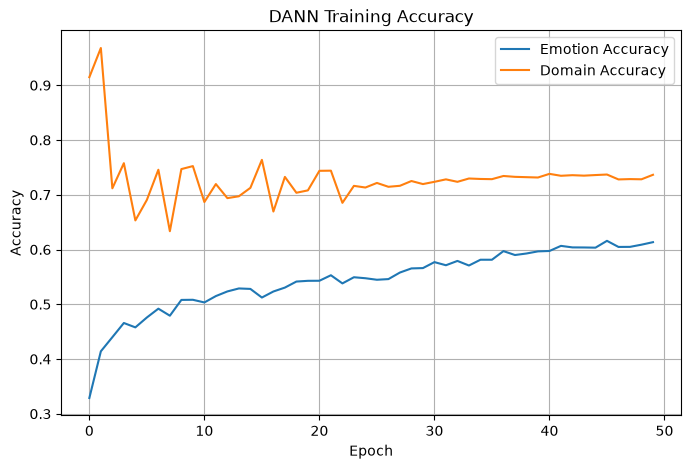

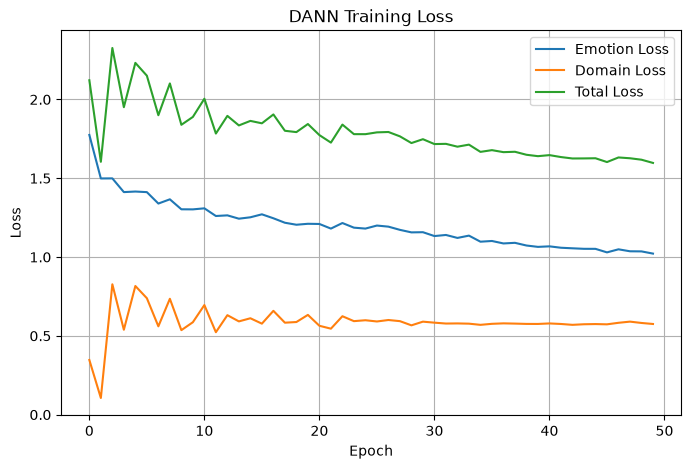

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["emotion_acc"],
    label="Emotion Accuracy"
)

plt.plot(
    history["domain_acc"],
    label="Domain Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DANN Training Accuracy")
plt.legend()
plt.grid(True)

plt.show()
plt.figure(figsize=(8, 5))

plt.plot(
    history["emotion_loss"],
    label="Emotion Loss"
)

plt.plot(
    history["domain_loss"],
    label="Domain Loss"
)

plt.plot(
    history["total_loss"],
    label="Total Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DANN Training Loss")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
model.eval()

emotion_predictions = []
emotion_actual = []

domain_predictions = []
domain_actual = []

with torch.no_grad():

    for X_batch, y_emotion_batch, y_domain_batch in test_loader:

        X_batch = X_batch.to(device)

        emotion_output, domain_output, _ = model(
            X_batch,
            lambda_=1.0
        )

        emotion_pred = emotion_output.argmax(dim=1)
        domain_pred = domain_output.argmax(dim=1)

        emotion_predictions.extend(
            emotion_pred.cpu().numpy()
        )

        emotion_actual.extend(
            y_emotion_batch.numpy()
        )

        domain_predictions.extend(
            domain_pred.cpu().numpy()
        )

        domain_actual.extend(
            y_domain_batch.numpy()
        )
emotion_accuracy = accuracy_score(
    emotion_actual,
    emotion_predictions
)

print("Emotion accuracy:", emotion_accuracy)

print(
    classification_report(
        emotion_actual,
        emotion_predictions,
        target_names=emotion_encoder.classes_
    )
)

Emotion accuracy: 0.6295399515738499
              precision    recall  f1-score   support

       angry       0.72      0.78      0.75       331
        calm       0.86      0.84      0.85        77
     disgust       0.58      0.55      0.57       331
     fearful       0.62      0.53      0.57       331
       happy       0.60      0.56      0.58       331
     neutral       0.51      0.61      0.55       256
         sad       0.61      0.65      0.63       331
   surprised       0.94      0.79      0.86        77

    accuracy                           0.63      2065
   macro avg       0.68      0.67      0.67      2065
weighted avg       0.63      0.63      0.63      2065



In [19]:
domain_accuracy = accuracy_score(
    domain_actual,
    domain_predictions
)

print("Domain classification accuracy:", domain_accuracy)

print(
    classification_report(
        domain_actual,
        domain_predictions,
        target_names=domain_encoder.classes_
    )
)

Domain classification accuracy: 0.7380145278450363
              precision    recall  f1-score   support

     CREMA-D       0.73      1.00      0.85      1488
     RAVDESS       0.93      0.07      0.13       577

    accuracy                           0.74      2065
   macro avg       0.83      0.53      0.49      2065
weighted avg       0.79      0.74      0.64      2065



In [20]:
model.eval()

all_features = []
all_emotions = []
all_domains = []

full_dataset = SpeechDataset(
    X,
    y_emotion,
    y_domain
)

full_loader = DataLoader(
    full_dataset,
    batch_size=256,
    shuffle=False
)

with torch.no_grad():

    for X_batch, y_emotion_batch, y_domain_batch in full_loader:

        X_batch = X_batch.to(device)

        _, _, features = model(
            X_batch,
            lambda_=1.0
        )

        all_features.append(
            features.cpu().numpy()
        )

        all_emotions.extend(
            y_emotion_batch.numpy()
        )

        all_domains.extend(
            y_domain_batch.numpy()
        )

speech_embeddings = np.vstack(all_features)

print("Speech embedding shape:", speech_embeddings.shape)

Speech embedding shape: (10322, 64)


In [22]:
embedding_cols = [
    f"speech_emb_{i+1}"
    for i in range(speech_embeddings.shape[1])
]

embedding_df = pd.DataFrame(
    speech_embeddings,
    columns=embedding_cols
)

embedding_df["emotion"] = emotion_encoder.inverse_transform(
    np.array(all_emotions)
)

embedding_df["dataset"] = domain_encoder.inverse_transform(
    np.array(all_domains)
)

embedding_df["file_id"] = df["file_id"].values

output_file = "../data/processed/speech_dann_embeddings.csv"

embedding_df.to_csv(
    output_file,
    index=False
)

print("Saved:", output_file)
print("Shape:", embedding_df.shape)

Saved: ../data/processed/speech_dann_embeddings.csv
Shape: (10322, 67)


In [23]:
model_path = "../data/processed/dann_speech_model.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "feature_cols": feature_cols,
        "emotion_classes": emotion_encoder.classes_.tolist(),
        "domain_classes": domain_encoder.classes_.tolist()
    },
    model_path
)

print("Model saved:", model_path)

Model saved: ../data/processed/dann_speech_model.pth


In [24]:
print("Emotion classification accuracy:", emotion_accuracy)

print(
    classification_report(
        emotion_actual,
        emotion_predictions,
        target_names=emotion_encoder.classes_
    )
)

Emotion classification accuracy: 0.6295399515738499
              precision    recall  f1-score   support

       angry       0.72      0.78      0.75       331
        calm       0.86      0.84      0.85        77
     disgust       0.58      0.55      0.57       331
     fearful       0.62      0.53      0.57       331
       happy       0.60      0.56      0.58       331
     neutral       0.51      0.61      0.55       256
         sad       0.61      0.65      0.63       331
   surprised       0.94      0.79      0.86        77

    accuracy                           0.63      2065
   macro avg       0.68      0.67      0.67      2065
weighted avg       0.63      0.63      0.63      2065



[[1485    3]
 [ 538   39]]


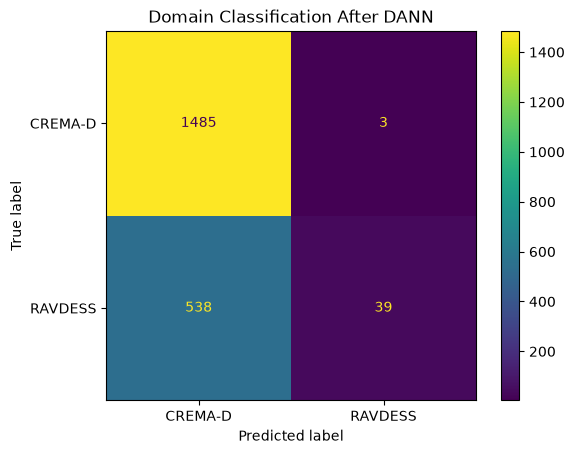

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    domain_actual,
    domain_predictions
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=domain_encoder.classes_
)

disp.plot()
plt.title("Domain Classification After DANN")
plt.show()